# Начало

В данном блокноте мы рассмотрим применение методов машинного обучения для решения важной задачи в области теплофизики - прогнозирования критического теплового потока (Critical Heat Flux, CHF).

Критический тепловой поток – это максимальное количество тепла, которое может быть передано от нагретой поверхности к кипящей жидкости без резкого ухудшения теплопередачи. Превышение CHF приводит к быстрому повышению температуры поверхности, что может вызвать повреждение оборудования, особенно в таких критических системах, как ядерные реакторы, высокопроизводительная электроника и другие теплообменные аппараты. Поэтому точное прогнозирование CHF крайне важно для обеспечения безопасной и эффективной работы этих систем.

Будем использовать набор данных из статьи "[On the prediction of critical heat flux using a physics-informed machine learning-aided framework](https://www.sciencedirect.com/science/article/am/pii/S1359431119332065)". В оригинальной статье авторы сравнивают традиционные физические модели, модели машинного обучения и гибридные модели (сочетающие физику и машинное обучение).  В данном блокноте мы сосредоточимся исключительно на моделях машинного обучения (ML) для прогнозирования CHF.

# Описание признаков

Мы будем использовать следующие признаки для прогнозирования CHF:

*   `author`: источник данных (публикация)
*   `geometry`: геометрия канала: труба, кольцо и т.д.
*   `pressure [MPa]`: Давление в системе (в мегапаскалях).
*   `mass_flux [kg/m2-s]`: Массовый расход жидкости (в килограммах на квадратный метр в секунду).
*   `x_e_out [-]`: Равновесное качество пара на выходе из канала (безразмерная величина).  Показывает долю пара в потоке.
*   `D_e [mm]`: Эквивалентный диаметр канала (в миллиметрах).
*   `D_h [mm]`: Гидравлический диаметр канала (в миллиметрах).
*   `length [mm]`: Длина нагреваемого участка канала (в миллиметрах).

# Загрузка данных и импорт библиотек

In [ ]:
!gdown 1SpeYHAevfOmZR7AbchCkg5z6ReqnbdEc

Downloading...
From: https://drive.google.com/uc?id=1SpeYHAevfOmZR7AbchCkg5z6ReqnbdEc
To: /content/Data_CHF_Zhao_2020_ATE.csv
100% 103k/103k [00:00<00:00, 12.0MB/s]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

In [ ]:
df = pd.read_csv('/content/Data_CHF_Zhao_2020_ATE.csv', index_col='id')
df.head()

,author,geometry,pressure [MPa],mass_flux [kg/m2-s],x_e_out [-],D_e [mm],D_h [mm],length [mm],chf_exp [MW/m2]
id,,,,,,,,,
1,Inasaka,tube,0.39,5600,-0.1041,3.0,3.0,100,11.3
2,Inasaka,tube,0.31,6700,-0.0596,3.0,3.0,100,10.6
3,Inasaka,tube,0.33,4300,-0.0395,3.0,3.0,100,7.3
4,Inasaka,tube,0.62,6400,-0.1460,3.0,3.0,100,12.8
5,Inasaka,tube,0.64,4700,-0.0849,3.0,3.0,100,11.0


Исключим из рассмотрения категориальные признаки

In [ ]:
df_base = df.drop(['author', 'geometry'], axis=1)
df_base.head()

,pressure [MPa],mass_flux [kg/m2-s],x_e_out [-],D_e [mm],D_h [mm],length [mm],chf_exp [MW/m2]
id,,,,,,,
1,0.39,5600,-0.1041,3.0,3.0,100,11.3
2,0.31,6700,-0.0596,3.0,3.0,100,10.6
3,0.33,4300,-0.0395,3.0,3.0,100,7.3
4,0.62,6400,-0.1460,3.0,3.0,100,12.8
5,0.64,4700,-0.0849,3.0,3.0,100,11.0


# Базовая модель

В качестве первого приближения, построим модель линейной регрессии "as is" без дополнительных манипуляций.

Разделим набор данных на тренировочную и тестовую выборки

In [ ]:
random_state=42

X_train, X_test, y_train, y_test = train_test_split(df_base.drop(['chf_exp [MW/m2]'], axis=1),  df_base['c'], test_size=0.2, random_state=random_state)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)  # Предсказание на тестовой выборке
mae_lr = mean_absolute_error(y_test, y_pred_lr)  # Оценка MAE
print(f'Linear Regression MAE: {mae_lr:.4f}')

Linear Regression MAE: 0.7778


# Анализ данных

Далее имеет смысл более детально взглянуть на данные. Возможно, это поможет нам получить более качественные результаты. Для начала построим матрицу выборочных корреляций.

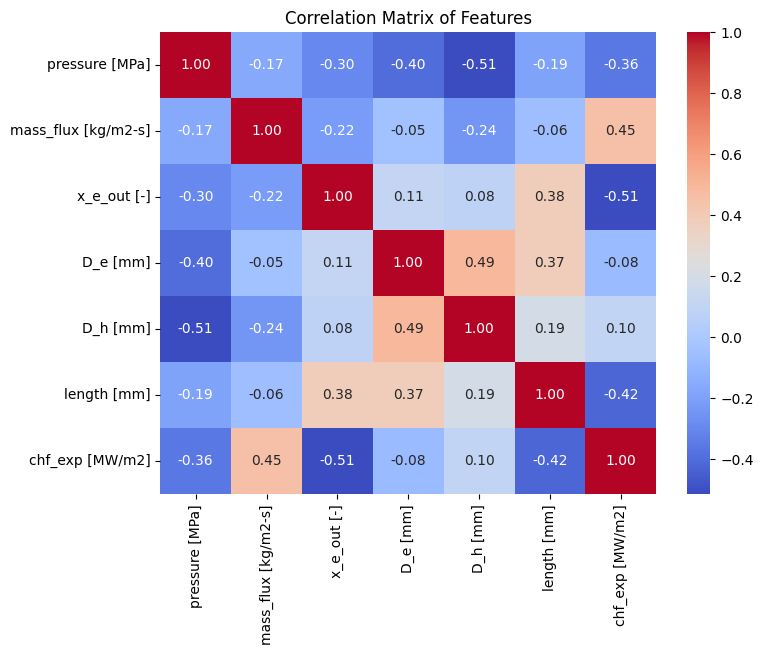

In [ ]:
correlation_matrix = df_base.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Features")
plt.show()

Можно заметить, что для некоторых пар признаков модуль выборочной корреляции находится в районе 0.5, однако, этот показатель недостаточно высок, чтобы предпринимать какие-либо действия.

Посмотрим на зависимость отклика от признаков: насколько она близка к линейной

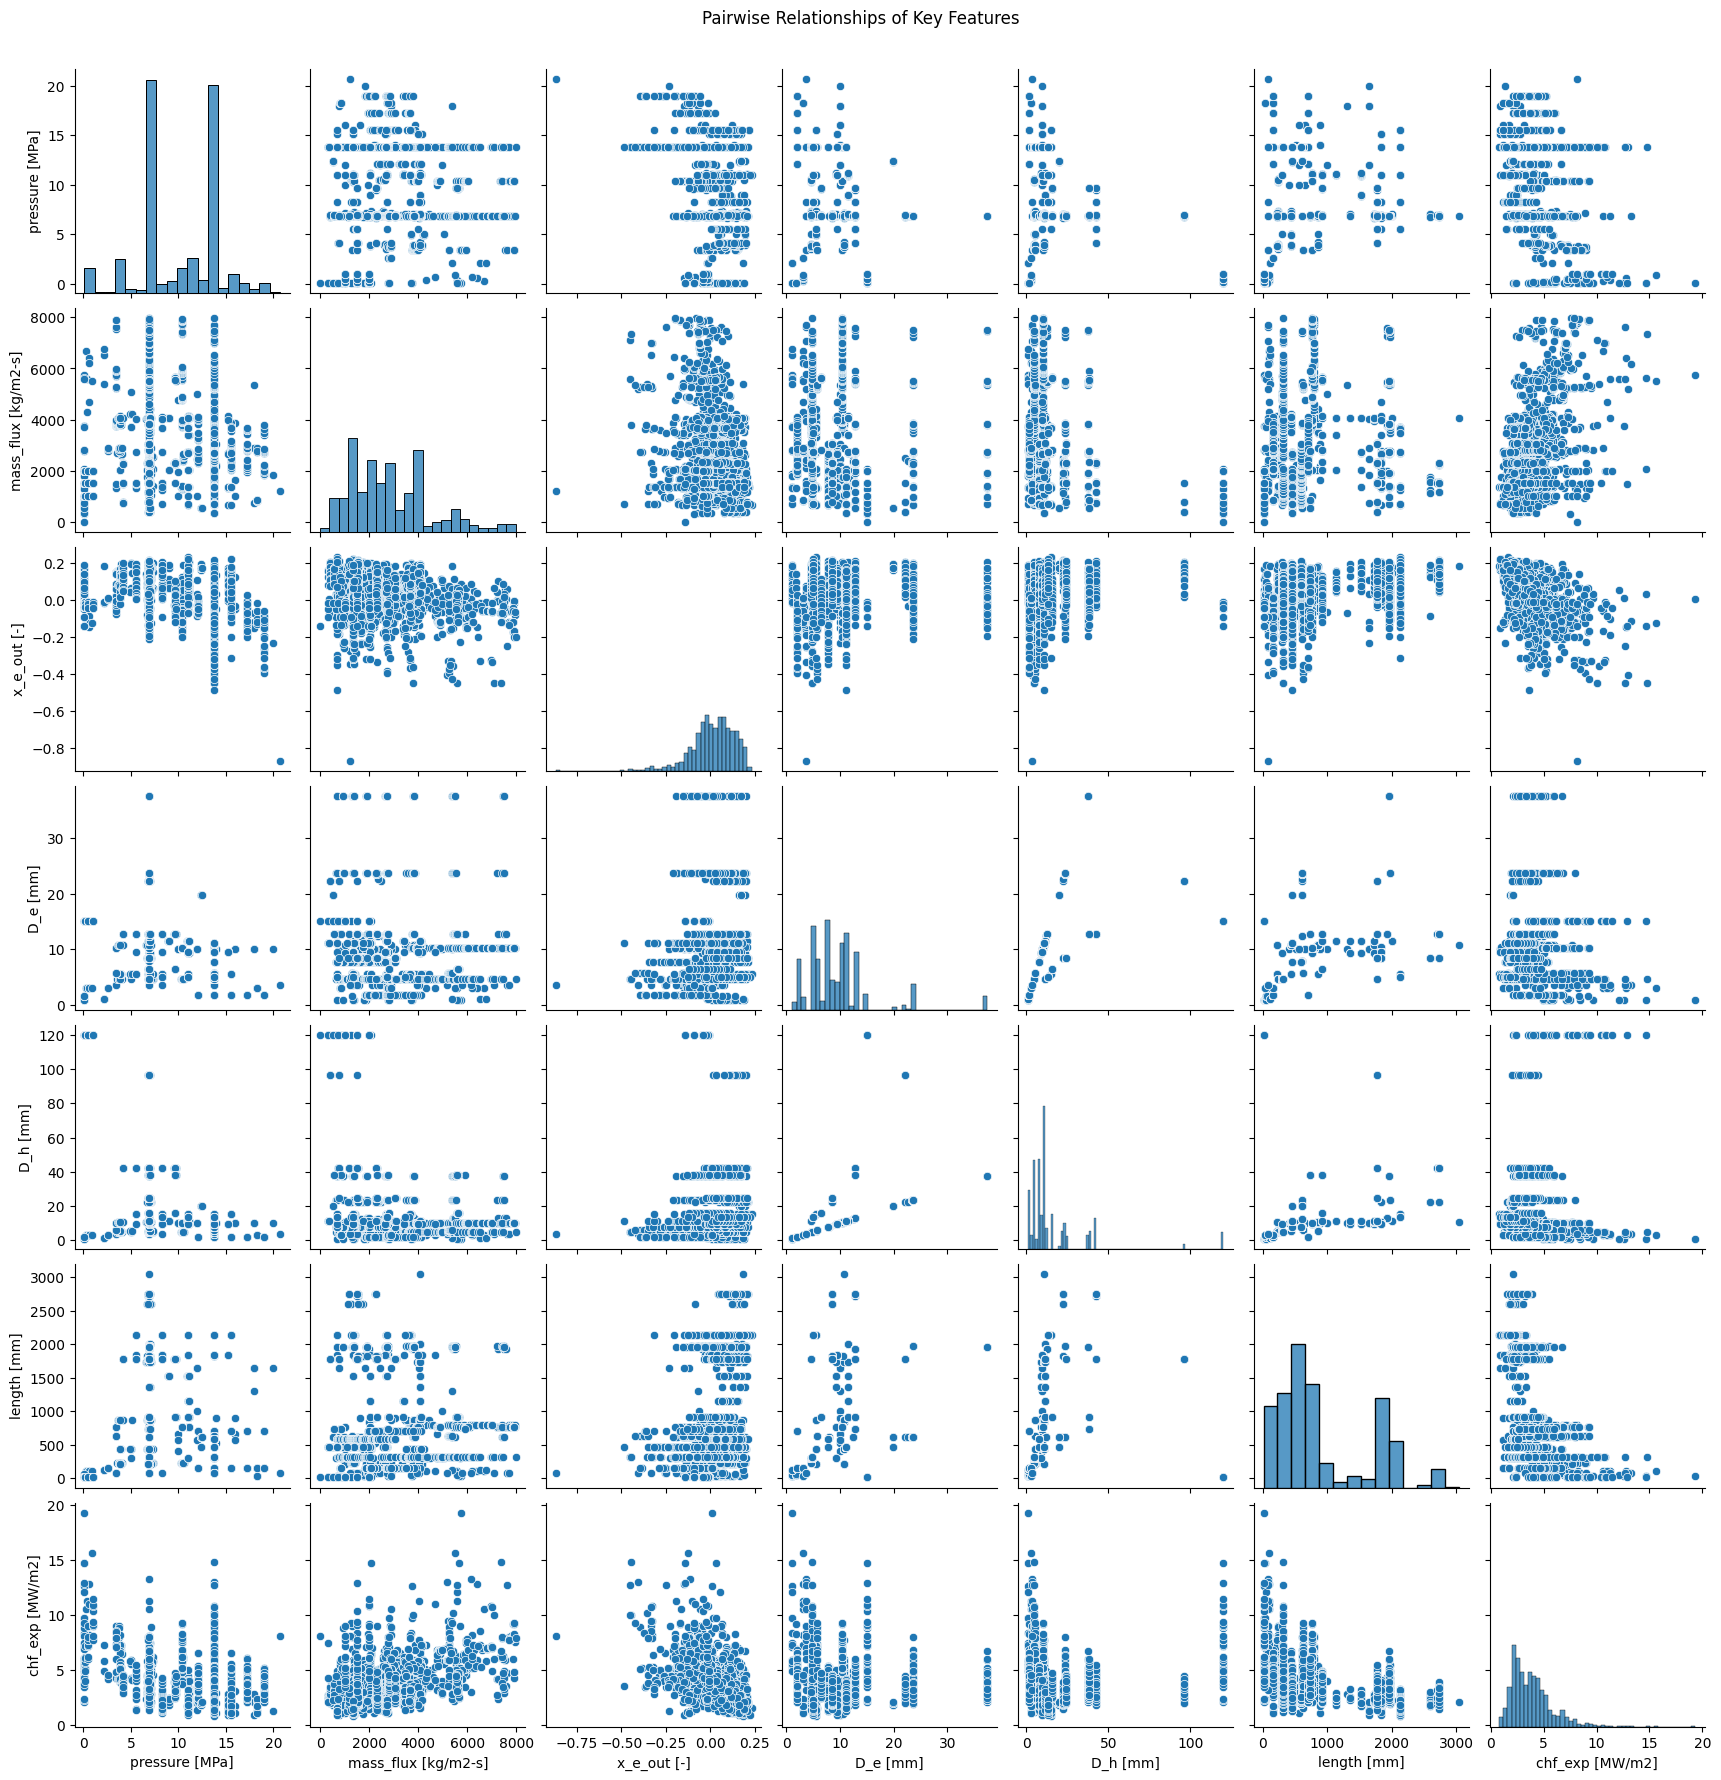

In [ ]:
sns.pairplot(df, vars=df_base.columns)
plt.suptitle("Pairwise Relationships of Key Features", y=1.02)  # y регулирует положение заголовка
plt.show()

Ничего такого, что явно привлекало бы внимание. Разве что можно попробовать извлечь корень из признака `length [mm]` и проверить, улучшится ли качество модели

# Распрямление признаков

In [ ]:
df_straightened = df_base.copy()
df_straightened['length [mm]'] = df_straightened['length [mm]']**0.5

X_train, X_test, y_train, y_test = train_test_split(df_straightened.drop(['chf_exp [MW/m2]'], axis=1),  df_straightened['chf_exp [MW/m2]'], test_size=0.2, random_state=random_state)
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)  # Предсказание на тестовой выборке
mae_lr = mean_absolute_error(y_test, y_pred_lr)  # Оценка MAE
print(f'Linear Regression MAE: {mae_lr:.4f}')

Linear Regression MAE: 0.7634


Качество незначительно подросло

# SVR

Рассмотрим регрессор на основе метода опорных векторов. Предварительно произведем нормировку данных

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df_base.drop(['chf_exp [MW/m2]'], axis=1),  df_base['chf_exp [MW/m2]'], test_size=0.2, random_state=random_state)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled )
print(X_test_scaled)

[[ 0.86993733  0.82595411  0.21366251 -0.74952464 -0.54379785 -0.81359239]
 [-0.7388329   1.7297796  -0.34560549  0.14724741 -0.27776395 -0.19861693]
 [ 0.46891055  0.55938806 -0.16514154 -1.19791066 -0.6768148  -1.04351565]
 ...
 [ 0.86993733 -0.79605268  1.45392654 -0.74952464 -0.54379785 -0.81359239]
 [-0.41707885 -0.89899002  1.32794228 -0.60540056 -0.04498428  1.70171266]
 [ 1.27096411 -0.3605028  -0.73462448 -1.19791066 -0.6768148  -1.04351565]]
[[-0.7388329   0.67244062 -0.38476276  0.14724741 -0.27776395 -0.19861693]
 [-0.7388329  -0.07787139 -0.0340498   4.50299736  1.01440071  1.4510132 ]
 [-1.73207365 -0.06180603 -0.07235583 -1.02175901 -0.62455814 -1.04628581]
 ...
 [ 0.06555221  0.63197971 -0.687806    0.14724741 -0.27776395 -0.19861693]
 [-0.7388329   0.84201947 -0.35667168  0.14724741 -0.27776395 -0.15429437]
 [-0.71318584  0.38207404  1.47520767 -0.60540056 -0.5010424  -0.65569328]]


Рассмотрим разные типы ядер

In [ ]:
svr = SVR(kernel='linear')  # Используем SVR с линейным ядром
svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
print(f'SVR linear MAE: {mae_svr:.4f}')

svr = SVR(kernel='poly')  # Используем SVR с полиномиальным ядром
svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
print(f'SVR polynomial MAE: {mae_svr:.4f}')

svr = SVR(kernel='rbf')  # Используем SVR с RBF ядром
svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
print(f'SVR RBF MAE: {mae_svr:.4f}')

SVR linear MAE: 0.7589
SVR polynomial MAE: 0.7712
SVR RBF MAE: 0.4325


Можно заметить, что использование более сложной модели (SVR с RBF ядром) было оправдано.

# Градиентный бустинг

Попробуем применить еще более сложную модель на основе градиентного бустинга. В данном случае нет необходимости нормировать данные

In [ ]:
gbr = GradientBoostingRegressor(random_state=random_state)  # Фиксируем random_state для воспроизводимости
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
print(f'Gradient Boosting Regressor MAE: {mae_gbr:.4f}')

Gradient Boosting Regressor MAE: 0.4088


Метрика еще немного улучшилась

Рассмотренный пример является хорошей отправной точкой для изучения применения ML в теплофизике. Для дальнейшего развития необходимо рассмотреть гибридные модели (как, например, в описанной в начале статье), более глубокий анализ признаков и более сложные методы машинного обучения. Оригинальная статья предоставляет ценную информацию о том, как можно интегрировать физические знания с ML для достижения наилучших результатов.